# 311 Service Requests from Louisville, KY in 2025
### Exploratory Data Analysis

Import libraries and data, then get the shape and scope of the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

lou311 = pd.read_csv('metro_311_2025.csv')
print(lou311.info())

<class 'pandas.DataFrame'>
RangeIndex: 182490 entries, 0 to 182489
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   service_request_id  182490 non-null  str    
 1   requested_datetime  182490 non-null  str    
 2   probyear            182490 non-null  int64  
 3   updated_datetime    136948 non-null  str    
 4   closed_date         122547 non-null  str    
 5   status_description  182490 non-null  str    
 6   status_notes        0 non-null       float64
 7   source              106785 non-null  str    
 8   service_name        182490 non-null  str    
 9   description         115872 non-null  str    
 10  agency_responsible  20296 non-null   str    
 11  address             129116 non-null  str    
 12  longitude           182490 non-null  float64
 13  latitude            182490 non-null  float64
 14  zip_code            127137 non-null  object 
 15  council_district    132913 non-null  object 


/tmp/ipykernel_24346/1097768212.py:5: DtypeWarning: Columns (0: source, 1: description, 2: zip_code, 3: council_district) have mixed types. Specify dtype option on import or set low_memory=False.
  lou311 = pd.read_csv('metro_311_2025.csv')


Python provides the warning:

    DtypeWarning: Columns (0: source, 1: description, 2: zip_code, 3: council_district) have mixed types.

Date columns are also stored as strings.

Re-read the CSV, converting mixed type columns to strings, and parse date columns as dates.

In [2]:
# create a dictionary to help assign new data types to mixed type columns
dtype_fix = {'source': 'str', 'description': 'str', 'zip_code': 'str', 'council_district': 'str'}
# re-read the CSV using the new data type assignments and interpret the dates as dates
lou311 = pd.read_csv('metro_311_2025.csv', dtype=dtype_fix, parse_dates=['requested_datetime', 'updated_datetime', 'closed_date'])

print(lou311.info())

print('= = = = = = = = = = = = = = = = = = = =')

print('# of unique values per column:')
print(lou311.nunique())

<class 'pandas.DataFrame'>
RangeIndex: 182490 entries, 0 to 182489
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   service_request_id  182490 non-null  str           
 1   requested_datetime  182490 non-null  datetime64[us]
 2   probyear            182490 non-null  int64         
 3   updated_datetime    136948 non-null  datetime64[us]
 4   closed_date         122547 non-null  datetime64[us]
 5   status_description  182490 non-null  str           
 6   status_notes        0 non-null       float64       
 7   source              106785 non-null  str           
 8   service_name        182490 non-null  str           
 9   description         115872 non-null  str           
 10  agency_responsible  20296 non-null   str           
 11  address             129116 non-null  str           
 12  longitude           182490 non-null  float64       
 13  latitude            182490 non-null  flo

### Data Cleaning

Which columns have missing data?

In [3]:
print(lou311.isnull().sum())

service_request_id         0
requested_datetime         0
probyear                   0
updated_datetime       45542
closed_date            59943
status_description         0
status_notes          182490
source                 75705
service_name               0
description            66618
agency_responsible    162194
address                53374
longitude                  0
latitude                   0
zip_code               55353
council_district       49577
ObjectId                   0
x                          0
y                          0
dtype: int64


Because the number of null values in *status_notes* is equal to the total number of rows, *status_notes* is an unused column to be dropped.

The last three columns, *ObjectId*, *x*, and *y* all have entries in every row, but the source webpage at data.louisvilleky.gov makes no mention of these columns in the detailed dataset description. 


A glance at *ObjectId* reveals it to be a simple counter, and so functionally indistinguishable from the baseline index values.


In [4]:
print(lou311['ObjectId'].head(10))

0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    10
Name: ObjectId, dtype: int64


From the *.nunique* output ("# of unique values" table above), *x* has the same number of entries as *longitude*, and *y* has the same number of entries as *latitude*.

Are they, in fact, the same?

In [5]:
# sort both x and longitude then compare
x_asc = lou311['x'].sort_values()
long_asc = lou311['longitude'].sort_values()
print('Column x = column longitude: ', x_asc.equals(long_asc))
# sort both y and latitude then compare
y_asc = lou311['y'].sort_values()
lat_asc = lou311['latitude'].sort_values()
print('Column y = column latitude: ', y_asc.equals(lat_asc))

Column x = column longitude:  False
Column y = column latitude:  False


*x* and *y* are apparently **not** *longitude* and *latitude*. 

That the number of unique values matching between this pair of pairs is likely more than coincidental. But since they cannot be reliably identified and are not described by the source, they are dropped from the cleaned data set. The original data set is retained in case it is needed later.

Ultimately, the columns *status_notes*, *ObjectId*, *x*, and *y* are dropped.

In [6]:
lou311_clean = lou311.drop(labels = ['status_notes', 'ObjectId', 'x', 'y'], axis='columns')
lou311_clean.columns

Index(['service_request_id', 'requested_datetime', 'probyear',
       'updated_datetime', 'closed_date', 'status_description', 'source',
       'service_name', 'description', 'agency_responsible', 'address',
       'longitude', 'latitude', 'zip_code', 'council_district'],
      dtype='str')

In [7]:
print(lou311_clean.info())

<class 'pandas.DataFrame'>
RangeIndex: 182490 entries, 0 to 182489
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   service_request_id  182490 non-null  str           
 1   requested_datetime  182490 non-null  datetime64[us]
 2   probyear            182490 non-null  int64         
 3   updated_datetime    136948 non-null  datetime64[us]
 4   closed_date         122547 non-null  datetime64[us]
 5   status_description  182490 non-null  str           
 6   source              106785 non-null  str           
 7   service_name        182490 non-null  str           
 8   description         115872 non-null  str           
 9   agency_responsible  20296 non-null   str           
 10  address             129116 non-null  str           
 11  longitude           182490 non-null  float64       
 12  latitude            182490 non-null  float64       
 13  zip_code            127137 non-null  str

Are there any truly duplicate rows?

In [8]:
lou311_clean.duplicated().sum()

np.int64(0)

No duplicate rows.

## Questions About ZIP Codes
* How many ZIP codes are represented?
* Which ZIP codes most frequently utilize 311 services?
* Do the types of service requests vary by ZIP code? If so, are there identifiable patterns to what types of requests are made from where?

**Further investigation on ZIP codes**
* Many entries are missing zip_code, but no entires are missing latitude or longitude. 
* Is there a discernable reason so many entries missing *zip_code*? 
* How many entries are missing *zip_code*?
* If needed, can *zip_code* be derived from a combination of *latitude* and *longitude*? 
* If needed, could the same process to backfill *zip_code* be used for *council_district*?

In [9]:
# count entries missing zip_code
missing_zips = lou311_clean['zip_code'].isnull().sum()
pct_missing_zips = lou311_clean['zip_code'].isnull().sum() / lou311_clean['service_request_id'].value_counts().sum() * 100

print('# of entries missing ZIP codes: ',  "{:,}".format(missing_zips))
print('% of entries missing ZIP codes: ', "{:.2f}".format(pct_missing_zips), "%")

print('- - -')

print('ZIP codes column info:')
print(lou311['zip_code'].describe())


# of entries missing ZIP codes:  55,353
% of entries missing ZIP codes:  30.33 %
- - -
ZIP codes column info:
count     127137
unique        43
top        40211
freq        9612
Name: zip_code, dtype: object


In [10]:
print(lou311_clean[lou311_clean['zip_code'].isnull()].nunique())

service_request_id    55353
requested_datetime      353
probyear                  1
updated_datetime        366
closed_date             354
status_description        2
source                    1
service_name             50
description           13482
agency_responsible       26
address                1764
longitude               829
latitude                826
zip_code                  0
council_district         27
dtype: int64


Nearly ***one third*** of all service requests in 2025 are missing an entry in the ZIP code column. 

Shifting the entries missing *zip_code* to their own dataframe, then grouping them by various columns like *service_name* or *agency_responsible* provides no clue as to *why* these entries are missing *zip_code*. Most likely, the ZIP code was simply not logged when the service request was made. 

In [11]:
no_zip = lou311_clean[lou311_clean['zip_code'].isnull()]

Some ZIP codes are also duplicated in the data, i.e. '40207' and '40207-0000', so those will be combined.

Three ZIP codes end with a '-0000' suffix while the others are only their typical 5-digit ZIP. Replace these '-0000' entries with their 5-digit counterparts for consolidation. 

Since the ZIP variable is a string, and there is seemingly no particular reason *zip_code* is missing from some entries, also replace NaN with "Unknown".

In [12]:
lou311_clean['zip_code'].unique()

<StringArray>
[     '40217',          nan,      '40210',      '40206',      '40204',
      '40219',      '40216',      '40205',      '40214',      '40212',
      '40207',      '40215',      '40258',      '40228',      '40211',
      '40299',      '40203',      '40213',      '40229',      '40218',
      '40023',      '40220',      '40222',      '40208',      '40291',
      '40272',      '40241',      '40245',      '40223',      '40059',
      '40177',      '40242',      '40118',      '40202',      '40243',
      '40209',      '40225',      '40025', '40219-0000',      '40041',
      '47130', '40207-0000', '40208-0000',      '40165']
Length: 44, dtype: str

In [13]:
# Consolidate the '-0000' ZIPs into their "correct" counterparts.
lou311_clean.replace({'zip_code': {'40207-0000': '40207', '40208-0000': '40208', '40219-0000': '40219'}}, inplace=True)
lou311_clean['zip_code'].unique()


<StringArray>
['40217',     nan, '40210', '40206', '40204', '40219', '40216', '40205',
 '40214', '40212', '40207', '40215', '40258', '40228', '40211', '40299',
 '40203', '40213', '40229', '40218', '40023', '40220', '40222', '40208',
 '40291', '40272', '40241', '40245', '40223', '40059', '40177', '40242',
 '40118', '40202', '40243', '40209', '40225', '40025', '40041', '47130',
 '40165']
Length: 41, dtype: str

In [14]:
# Swap the null ZIP codes for 'Unknown'
lou311_clean.fillna({'zip_code': 'Unknown'}, inplace=True)
lou311_clean[lou311_clean['zip_code'].isnull()]
lou311_clean[lou311_clean['zip_code'] == 'Unknown']

,service_request_id,requested_datetime,probyear,updated_datetime,closed_date,status_description,source,service_name,description,agency_responsible,address,longitude,latitude,zip_code,council_district
1,SR-MISC-25-000351,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Miscellaneous,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
2,SR-MTRO-25-000250,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Metro Agencies,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
3,SR-MTRO-25-000352,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Metro Agencies,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
5,SR-UTIL-25-000251,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Utility,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
6,SR-MTRO-25-000252,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Metro Agencies,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181968,SR-BAPT-25-112124,2025-07-25 04:00:00,2025,2025-07-25 04:00:00,2025-07-25 04:00:00,CLOSED,NaN,Large Item Appointment,NaN,NaN,140-199 N CRESTMOOR AVE,-85.740657,38.283469,Unknown,9
182025,SR-MSDS-25-151335,2025-10-10 04:00:00,2025,2025-10-10 04:00:00,NaT,OPEN,NaN,Solid Waste Missed Services,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
182044,SR-SIGN-25-119037,2025-08-07 04:00:00,2025,2025-08-12 04:00:00,2025-08-12 04:00:00,CLOSED,NaN,Street Signs,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
182091,SR-BAPT-25-091213,2025-06-17 04:00:00,2025,2025-06-17 04:00:00,2025-06-17 04:00:00,CLOSED,NaN,Large Item Appointment,NaN,NaN,NaN,-85.740657,38.283469,Unknown,3


### Visualizing number of service requests by ZIP code

- Determine whether 311 services are requested more or less frequently by neighborhood (*zip_code*)
- Pie chart selected to view contribution (count) to total service requests by ZIP code
- Default color scheme: distinct visual differences between slices

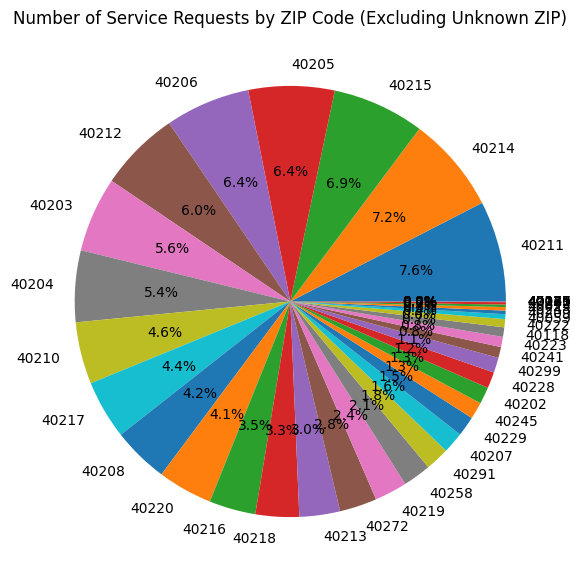

In [15]:
# count requests by ZIP code
tot_sr_zip = lou311_clean.value_counts(subset='zip_code').drop('Unknown')

# set a reasonable plot size
plt.figure(figsize=(7,7))

# plot a pie chart, exclude "Unknown" ZIP
plt.pie(tot_sr_zip, 
        autopct='%1.1f%%',
        labels=tot_sr_zip.index)
plt.title('Number of Service Requests by ZIP Code (Excluding Unknown ZIP)')
plt.show()

Crowded view with 40 ZIP codes represented, exluding 'Unknown'. Trim down to the top 10 ZIPs by number of requests made and view as a bar plot instead, since data does not consider the annual totals.

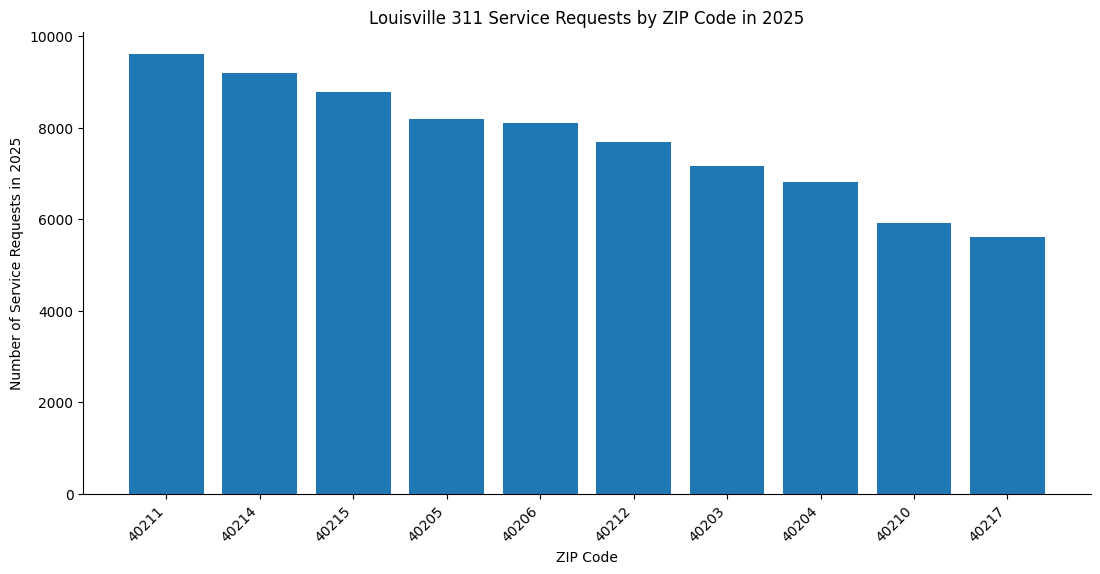

In [16]:
# get top 10 ZIP codes by service request count
top_sr_zip = tot_sr_zip.nlargest(10)

# set a reasonable plot size
plt.figure(figsize=(13,6))

# make it more readable
plt.xlabel("ZIP Code")
plt.ylabel("Number of Service Requests in 2025")
plt.title("Louisville 311 Service Requests by ZIP Code in 2025")
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.bar(top_sr_zip.index,top_sr_zip.values)

plt.show()


### Takeaways from ZIP Code EDA

Initial investigations into ZIP code show little of interest to explore further.

Examine other variables in this dataset. Most of them are strings, which reduces quantitative analysis to various counts. 

Begin by looking at unique values by category.

In [17]:
# print(lou311_clean.info())
print("Number of unique 'service_name': ", lou311_clean['service_name'].nunique())
print("Number of unique 'status_description': ", lou311_clean['status_description'].nunique())
print("Number of unique 'description': ", lou311_clean['description'].nunique())
print("Number of unique 'agency_responsible': ", lou311_clean['agency_responsible'].nunique())
print("Number of unique 'source': ", lou311_clean['source'].nunique())
print("Number of unique 'council_district': ", lou311_clean['council_district'].nunique())


Number of unique 'service_name':  55
Number of unique 'status_description':  2
Number of unique 'description':  103137
Number of unique 'agency_responsible':  35
Number of unique 'source':  2
Number of unique 'council_district':  28


*service_name* appears to be a reasonably condensed summary of what service is requested per 311 call. 

Which are the most requested services?

- Show which services are most requested
- Bar plot selected since pie chart would be far too crowded

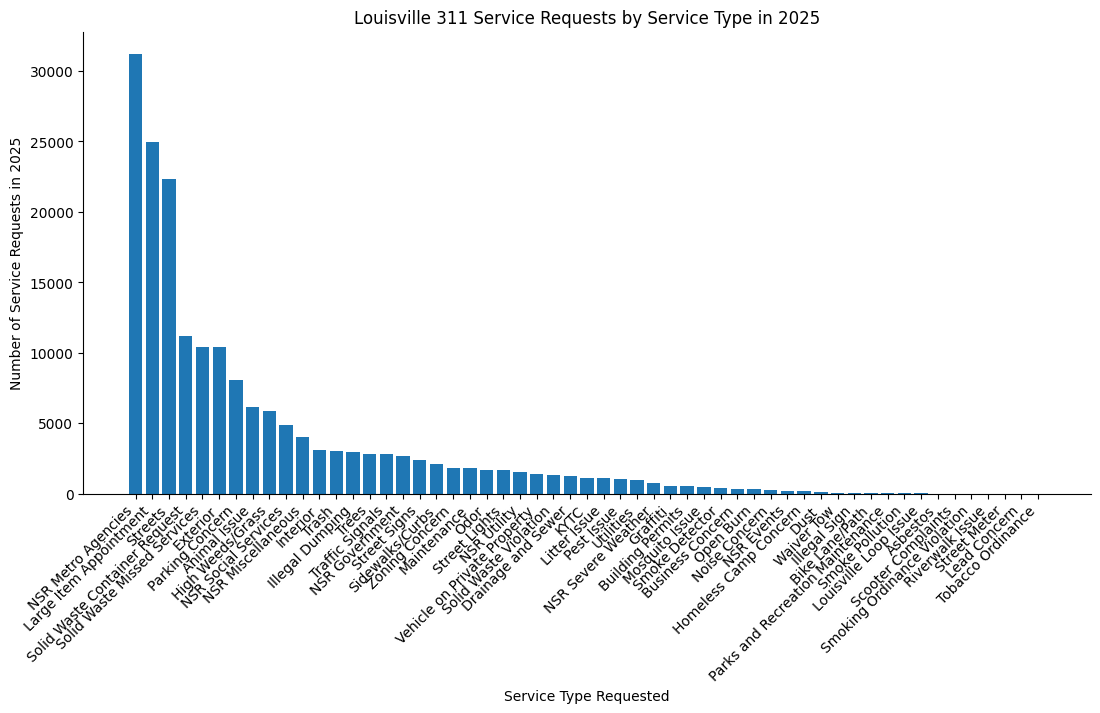

In [18]:
# count requests by service_name
svc_reqs = lou311_clean.value_counts(subset='service_name')

# set a reasonable plot size
plt.figure(figsize=(13,6))

# make it more readable
plt.xlabel("Service Type Requested")
plt.ylabel("Number of Service Requests in 2025")
plt.title("Louisville 311 Service Requests by Service Type in 2025")
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.bar(svc_reqs.index,svc_reqs.values)

plt.show()


From the source at https://data.louisvilleky.gov/datasets/LOJIC::louisville-metro-ky-metro-311-service-request-2025/about

> *Questions are answered and denoted into the reporting system as a Non-Service Request (NSR).*

Because this investigation is regarding the most requested *serivces*, questions aka NSR, should be considered separately. 


In [19]:
# isolate rows where service_name starts with "NSR " and commit to its own dataframe
lou311_nsr = lou311_clean.loc[lou311_clean['service_name'].str.startswith('NSR ')]

# lou311_sr becomes the dataframe that excludes NSR calls
lou311_sr = lou311_clean.drop(lou311_nsr.index)

Now, there is a clean read on true "service" requests, excluding items the city itself deems "non-service requests," i.e. calls for information only.

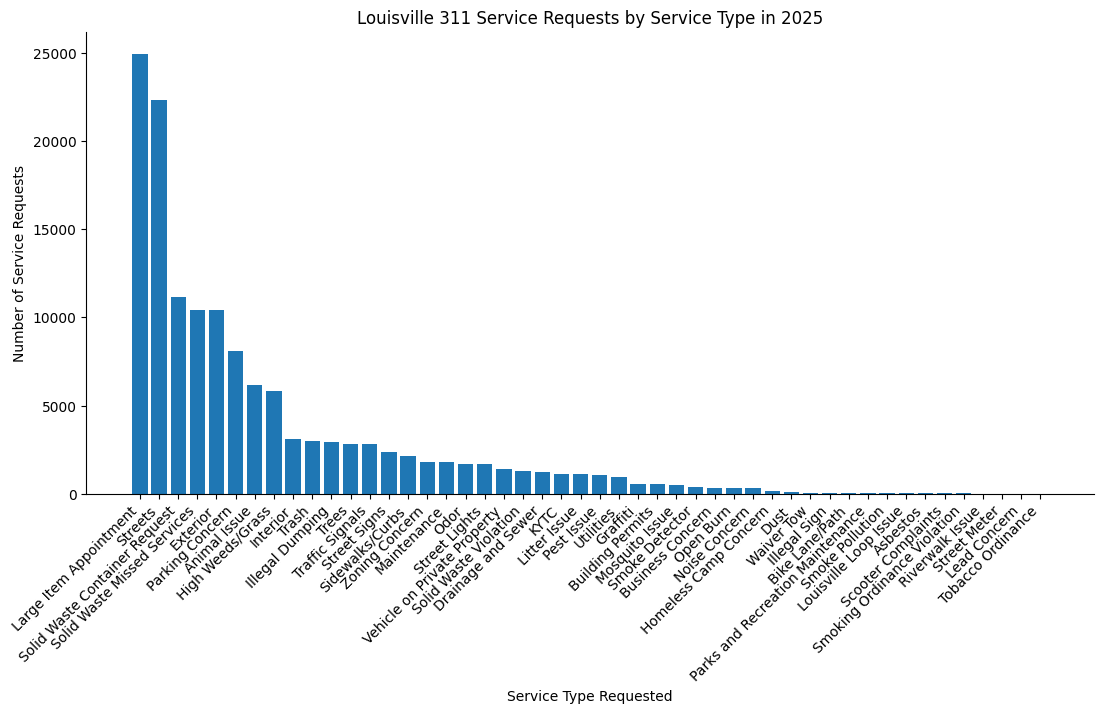

In [20]:
# count requests by service_name
sr_counts = lou311_sr.value_counts(subset='service_name')

# set a reasonable plot size
plt.figure(figsize=(13,6))

# make it more readable
plt.xlabel("Service Type Requested")
plt.ylabel("Number of Service Requests")
plt.title("Louisville 311 Service Requests by Service Type in 2025")
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.bar(sr_counts.index,sr_counts.values)

plt.show()


This view remains cumbersome, though. And the further down the list from most to least requested, it becomes essentially impossible to see the bars on the plot. Show top ten most requested services only.

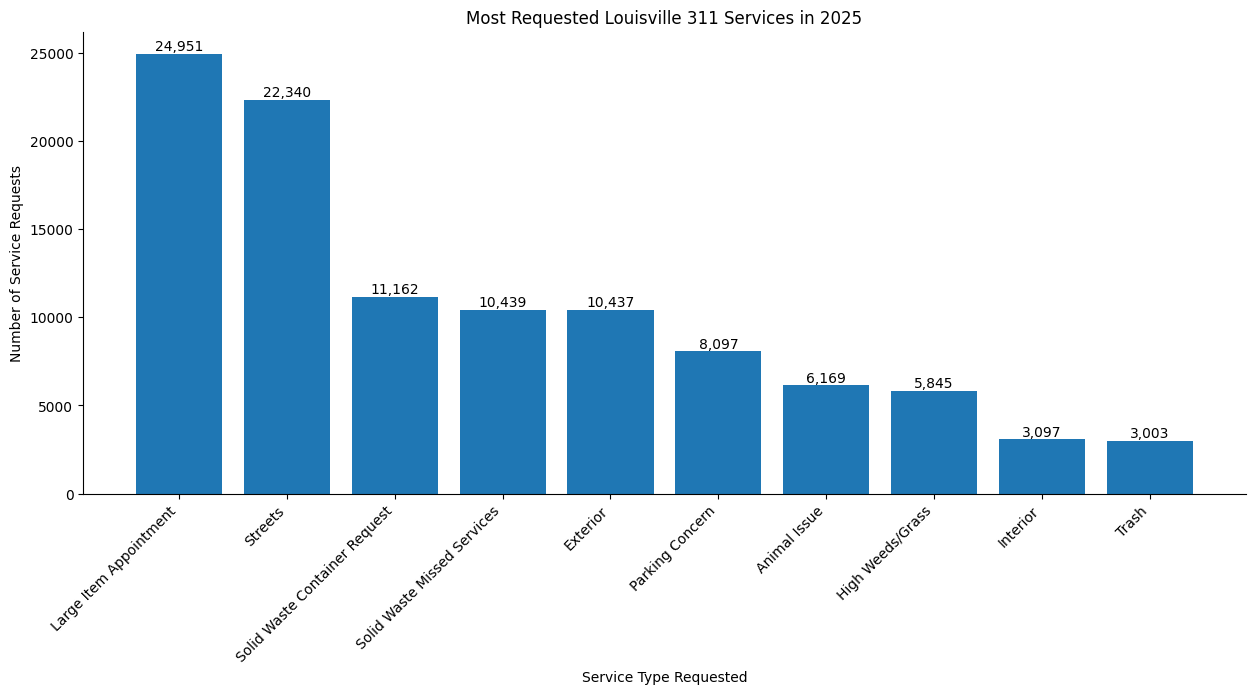

In [21]:
# count requests by service_name
top_sr = sr_counts.nlargest(10)

# set a reasonable plot size
plt.figure(figsize=(15,6))

# make it more readable
plt.xlabel("Service Type Requested")
plt.ylabel("Number of Service Requests")
plt.title("Most Requested Louisville 311 Services in 2025")
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.bar(top_sr.index,top_sr.values)

# add value labels to the bars
ax.bar_label(ax.containers[0],label_type='edge', fmt='{:,.0f}')

plt.show()


### Seeking a View of Service Requests as Percent Contribution to Annual Total

To view the percent contribution of each service request type (*service_name*) to the annual total, the number of pie slices must be reduced for readability.

Looking at no more than ten pie slices, break the series into the top 9 and bottom remainder. 

Large Item Appointment           24951
Streets                          22340
Solid Waste Container Request    11162
Solid Waste Missed Services      10439
Exterior                         10437
Parking Concern                   8097
Animal Issue                      6169
High Weeds/Grass                  5845
Interior                          3097
Other                            34725
dtype: int64


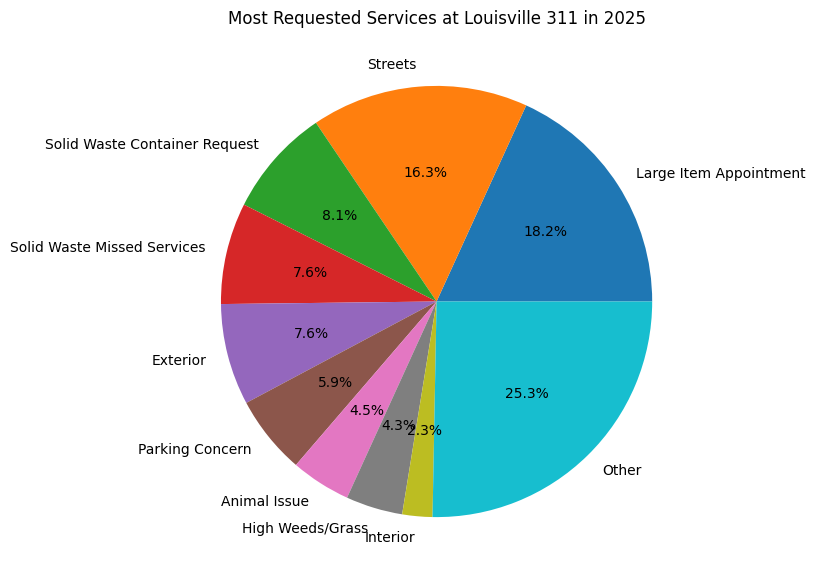

In [22]:
# set aside the top 9 service_name
sr_top9 = sr_counts.nlargest(9)

# create a new series that contains "all the rest" of service_name. 
# rather than count the number of service_name entries below 9, just take nsmallest and exclude the top 9.
# then give it an index value of "Other"
sr_bottom = pd.Series([sr_counts.nsmallest(len(sr_counts)-9).sum()])
sr_bottom.index = ['Other']

# combine Top 9 & Bottom Else (aka 10th)
sr_top10 = pd.concat([sr_top9, sr_bottom])

print(sr_top10)

# set a reasonable plot size
plt.figure(figsize=(7,7))

# plot a pie chart
plt.pie(sr_top10, 
        labels=sr_top10.index, 
        autopct='%1.1f%%')
plt.title('Most Requested Services at Louisville 311 in 2025')
plt.show()


At a glance, roughly half of all service requests are of just four types: 
- Large Item Appointment
- Streets
- Solid Waste Container Request
- Solid Waste Missed Services

Concern: This, like the ZIP code breakdown, still does not bring to mind any questions motivating a larger or deeper investigation.

### Service Request Types by Month

Use *requested_datetime* to group *service_name* by month.
First, split the service request counts by highest and lowest contribution to total, for ease of viewing when visualized.

Stacked bar plot specifically selected to show each service type (color-coded) in each month, but stacked or accumulated so that each month has one bar that sums to the total number of service requests in that month.

Text(0, 0.5, 'Number of Requests')

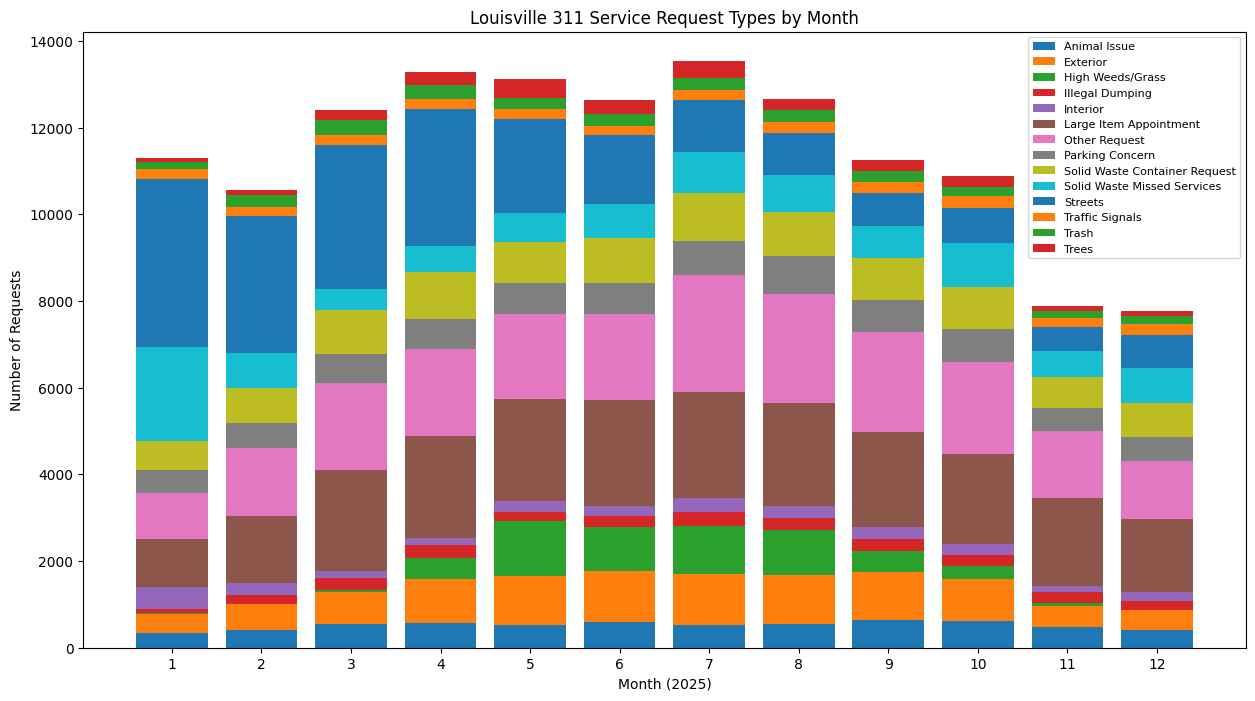

In [23]:
# demarcate the 75th percentile
top25mark = sr_counts.quantile(0.75)

# separate the service_name counts into top (biggest contributors) and bottom (smallest contributors)
top_list = sr_counts.index[sr_counts > top25mark].tolist()
bot_list = sr_counts.index[sr_counts < top25mark].tolist()

# add request month column from requested_datetime
lou311_sr['req_month'] = lou311_sr['requested_datetime'].dt.month

# change the lesser contributing service_name counts to "Other Request", but keep previous complete DataFrame
lou311_trimSR = lou311_sr.replace(to_replace=bot_list, value='Other Request')

grouped_trimSR = lou311_trimSR.groupby('req_month')['service_name'].value_counts()

# "unstack" that grouped_trimSR series to get the DataFrame needed
sr_byMonth = grouped_trimSR.unstack()

# loop the actual plotting to get the service request types (service_name) to accumulate (stack)
sum_count=0
fig = plt.figure(figsize=(15,8))
for col in sr_byMonth.columns:
    plt.bar(sr_byMonth.index, sr_byMonth[col], bottom=sum_count, label=col)
    sum_count = sum_count+sr_byMonth[col]

plt.xticks(sr_byMonth.index) # show all month labels
plt.legend(fontsize=8, loc='upper right') # small font for legend, move to upper right section
plt.title("Louisville 311 Service Request Types by Month")
plt.xlabel('Month (2025)')
plt.ylabel('Number of Requests')

Shrink this view by omitting "Other Request" types, looking at merely the 75th percentile of request types by count.

Text(0, 0.5, 'Number of Requests')

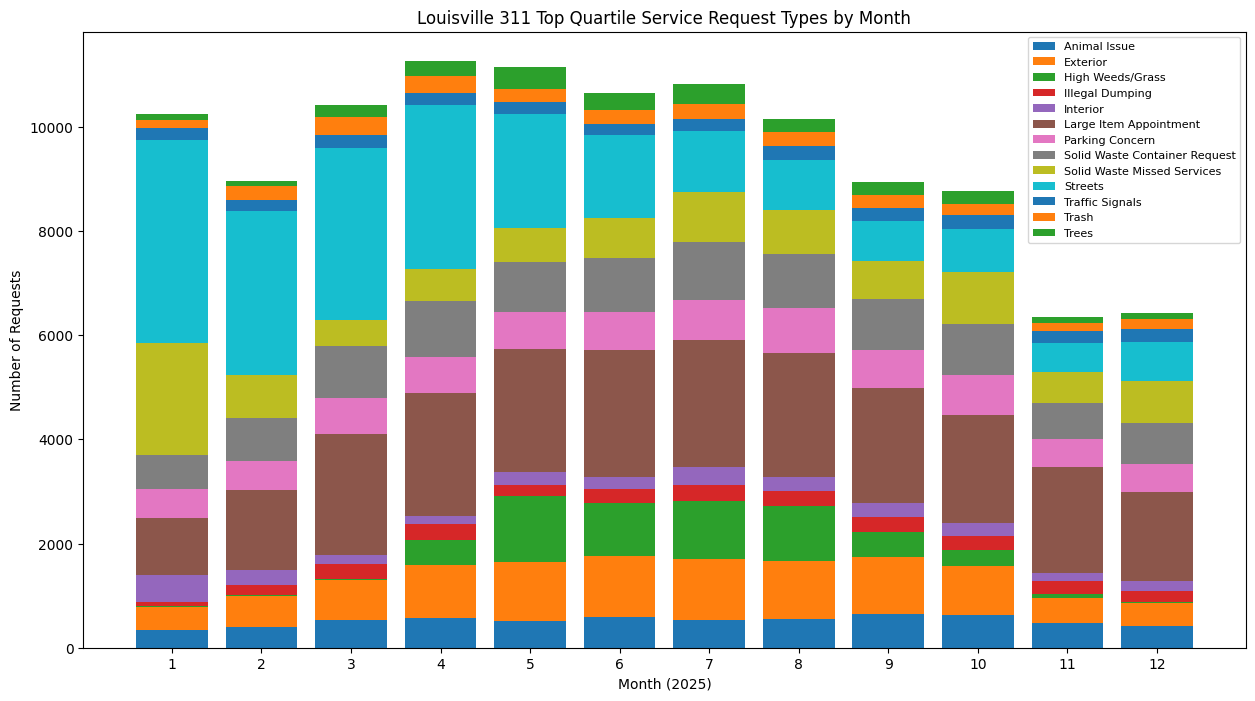

In [24]:
# drop "Other Request" entries
sr_byMo_topQ = sr_byMonth.drop('Other Request', axis=1)

# loop the actual plotting to get the service request types (service_name) to accumulate (stack)
sum_count=0
fig = plt.figure(figsize=(15,8))
for col in sr_byMo_topQ.columns:
    plt.bar(sr_byMo_topQ.index, sr_byMo_topQ[col], bottom=sum_count, label=col)
    sum_count = sum_count+sr_byMo_topQ[col]

plt.xticks(sr_byMo_topQ.index) # show all month labels
plt.legend(fontsize=8, loc='upper right') # small font for legend, move to upper right section
plt.title("Louisville 311 Top Quartile Service Request Types by Month")
plt.xlabel('Month (2025)')
plt.ylabel('Number of Requests')


## Summary and Conclusions

This EDA was meant to view 311 data in various was so as to inspire further investigation, or to glean some insight into who is using 311 services and for what purposes.

Unforunately, 25% of total entries were "non-service requests" (aka "NSR"). In attempting to assess service usage by ZIP code, it was found that one third of all requests had no affiliated ZIP code data. In reviewing service request counts by type (*service_name*) the results are unsurprising:
- Road concerns ("Streets") were more prevalent in late winter into spring, which is when one would expect potholes.
- "High Weeds/Grass" and "Exterior" both peak in the summer, which is also to be expected.
- "Solid Waste Missed Services" spikes somewhat in January, which is most likely attributable to poor weather leading to delayed waste pickup.
- Other categories vary much less from month to month or by season, suggesting that most of what communities need remains fairly consistent year-round.

Finally, because most of the data in this set is strings, analysis is limited largely to counting, or to functions associated with counting (means, sums, percent contribution, etc.). As a result, it is unclear whether this dataset will be ultimately prove suitable for use in a larger capstone project.